In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Divar.csv') 



C:\Users\Mahyar\AppData\Local\Temp\ipykernel_20508\436123264.py:5: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Divar.csv')


In [9]:

rent_data = df[df['cat2_slug'].str.contains('rent', case=False, na=False)].copy()
print("Number of rental listings:", rent_data.shape)

#datetime تبدیل رشته‌ی تاریخ به نوع  
rent_data['created_at_month'] = pd.to_datetime(rent_data['created_at_month'])

# بررسی مقادیر گمشده در ستون قیمت اجاره‌ی تبدیل‌شده
print("NaN  transformed_rent:", rent_data['transformed_rent'].isna().sum())

rent_data = rent_data.dropna(subset=['transformed_rent', 'created_at_month'])
print("  not NaN:", rent_data.shape)

Number of rental listings: (383028, 61)
NaN  transformed_rent: 310619
  not NaN: (72409, 61)


In [10]:
monthly_avg_rent = rent_data.groupby('created_at_month')['transformed_rent'].mean().reset_index()
monthly_avg_rent = monthly_avg_rent.sort_values('created_at_month')

monthly_avg_rent

,created_at_month,transformed_rent
0,2022-06-01,9.000000e+06
1,2023-10-01,1.750000e+07
2,2023-11-01,2.700000e+07
3,2023-12-01,6.602857e+07
4,2024-01-01,2.583333e+07
5,2024-02-01,6.777647e+07
6,2024-03-01,2.216667e+07
7,2024-04-01,3.693484e+07
8,2024-05-01,1.756049e+07
9,2024-06-01,1.569188e+07


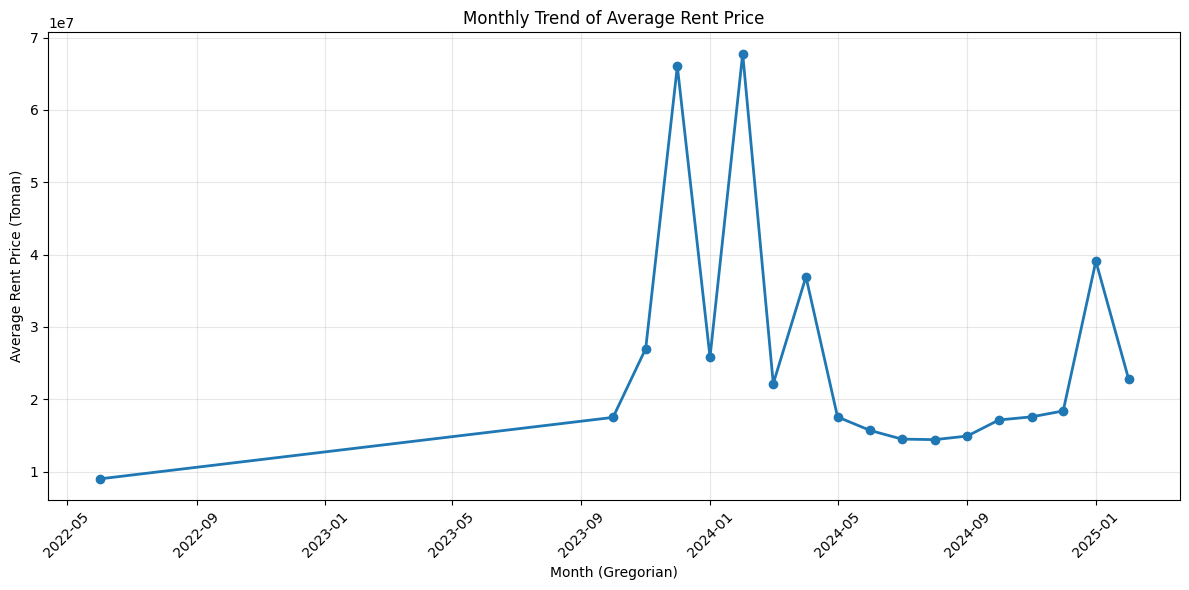

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_rent['created_at_month'], monthly_avg_rent['transformed_rent'], 
         marker='o', linewidth=2)
plt.xlabel('Month (Gregorian)')
plt.ylabel('Average Rent Price (Toman)')
plt.title('Monthly Trend of Average Rent Price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import jdatetime

def to_shamsi_label(gregorian_date):
    jd = jdatetime.date.fromgregorian(date=gregorian_date.date())
    month_names = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar',
                   'Mehr', 'Aban', 'Azar', 'Dey', 'Bahman', 'Esfand']
    return f"{month_names[jd.month - 1]} {jd.year}"

monthly_avg_rent['shamsi_month'] = monthly_avg_rent['created_at_month'].apply(to_shamsi_label)
monthly_avg_rent

,created_at_month,transformed_rent,shamsi_month
0,2022-06-01,9.000000e+06,Khordad 1401
1,2023-10-01,1.750000e+07,Mehr 1402
2,2023-11-01,2.700000e+07,Aban 1402
3,2023-12-01,6.602857e+07,Azar 1402
4,2024-01-01,2.583333e+07,Dey 1402
5,2024-02-01,6.777647e+07,Bahman 1402
6,2024-03-01,2.216667e+07,Esfand 1402
7,2024-04-01,3.693484e+07,Farvardin 1403
8,2024-05-01,1.756049e+07,Ordibehesht 1403
9,2024-06-01,1.569188e+07,Khordad 1403


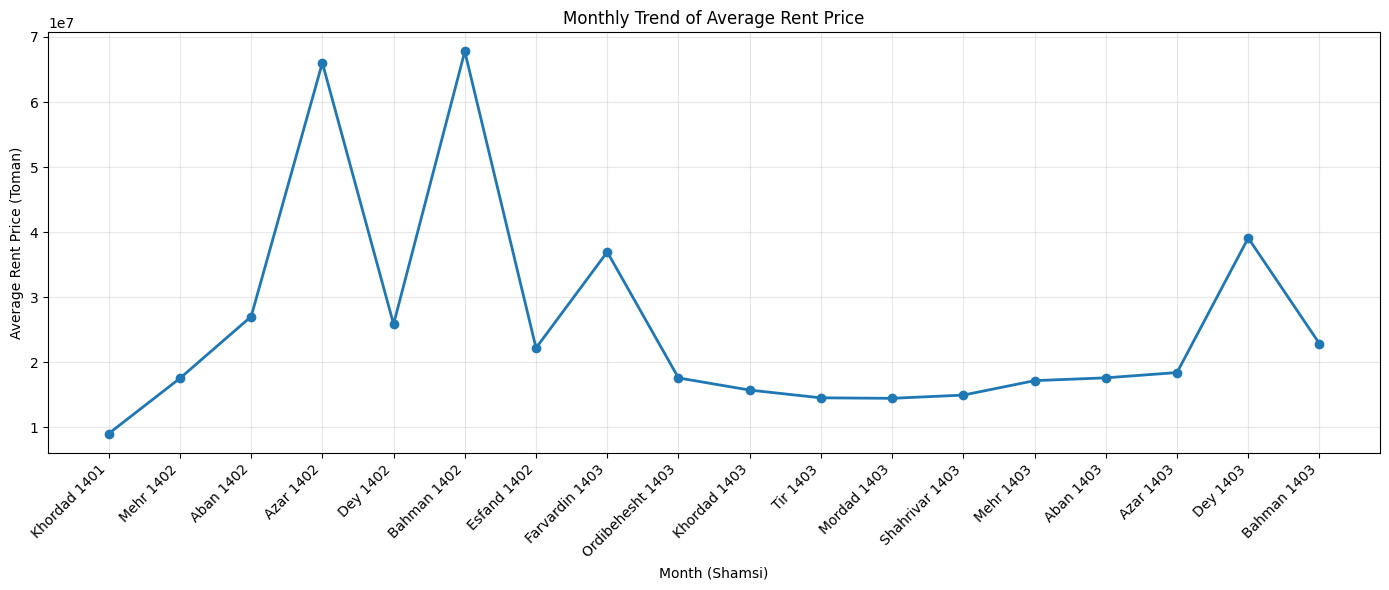

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_avg_rent['shamsi_month'], monthly_avg_rent['transformed_rent'], 
         marker='o', linewidth=2)
plt.xlabel('Month (Shamsi)')
plt.ylabel('Average Rent Price (Toman)')
plt.title('Monthly Trend of Average Rent Price')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
جمع‌بندی و نتیجه‌گیری
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
با بررسی روند ماهانه‌ی میانگین قیمت اجاره، ابتدا مشخص شد که تعداد آگهی‌های ثبت‌شده در ماه‌های ابتدایی داده (از خرداد ۱۴۰۱ تا اسفند ۱۴۰۲) بسیار اندک بوده است، به‌گونه‌ای که برخی ماه‌ها تنها یک تا چند آگهی ثبت‌شده داشته‌اند. به همین دلیل، میانگین محاسبه‌شده برای این بازه از نوسان شدید و غیرواقعی برخوردار بود و نمی‌توان آن را نماینده‌ی معتبری از روند بازار دانست.
    <br><br>
    از فروردین ۱۴۰۳ به بعد، تعداد آگهی‌ها به‌طور چشمگیری افزایش یافته و به چند هزار آگهی در هر ماه رسیده است؛ در نتیجه میانگین‌های محاسبه‌شده در این بازه از اعتبار آماری بسیار بیشتری برخوردارند. بر اساس همین بازه، روند میانگین قیمت اجاره در طول سال ۱۴۰۳ نسبتاً باثبات بوده و افزایش یا کاهش شدیدی مشاهده نمی‌شود.
    <br><br>
    لازم به ذکر است که دو ماه پایانی داده (دی و بهمن ۱۴۰۳) نیز به دلیل تعداد کم آگهی، احتمالاً به علت جمع‌آوری ناقص داده در این بازه‌ی زمانی، از اعتبار کمتری برخوردارند و باید در تفسیر روند نهایی با احتیاط در نظر گرفته شوند.
</font>
</p>